<a href="https://www.kaggle.com/code/lalit7881/diabetes-risk-prediction-eda-79-20?scriptVersionId=344360130" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib
matplotlib.use('Agg')  # Use Agg backend for matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Ensuring the backend is Agg when using pyplot
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/generate_dataset.py
/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/diabetes_risk.csv


## Loading dataset

In [2]:
# Ensure plots display inline (this is harmless even with Agg)
%matplotlib inline

from pathlib import Path

# Helper function to locate the data file
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

print('Imports and Setup complete.')

Imports and Setup complete.


In [3]:
file_path = resolve_data_file(file_name='diabetes_risk.csv', suffixes=['.csv'])
df = pd.read_csv(file_path, encoding='ascii', delimiter=',')

In [4]:
print('Data loaded successfully. DataFrame shape:', df.shape)

Data loaded successfully. DataFrame shape: (15000, 19)


In [5]:
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [7]:
df.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


In [8]:
df.isnull().sum()

patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64

In [9]:
df.dtypes

patient_id                    int64
age                           int64
gender                       object
city                         object
bmi                         float64
family_history_diabetes      object
physical_activity_level      object
diet_type                    object
smoking_status               object
alcohol_consumption          object
hours_sleep_per_night       float64
stress_level                  int64
fasting_blood_sugar           int64
hba1c_level                 float64
blood_pressure_systolic       int64
blood_pressure_diastolic      int64
waist_circumference_cm      float64
income_bracket               object
diabetes_risk                object
dtype: object

In [10]:
df.shape

(15000, 19)

In [11]:
df.columns

Index(['patient_id', 'age', 'gender', 'city', 'bmi', 'family_history_diabetes',
       'physical_activity_level', 'diet_type', 'smoking_status',
       'alcohol_consumption', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket',
       'diabetes_risk'],
      dtype='object')

In [12]:
df.nunique()

patient_id                  15000
age                            58
gender                          3
city                           18
bmi                           239
family_history_diabetes         2
physical_activity_level         3
diet_type                       4
smoking_status                  3
alcohol_consumption             3
hours_sleep_per_night          73
stress_level                   10
fasting_blood_sugar           273
hba1c_level                    71
blood_pressure_systolic        89
blood_pressure_diastolic       58
waist_circumference_cm        614
income_bracket                  3
diabetes_risk                   3
dtype: int64

## EDA

/tmp/ipykernel_16/42618630.py:3: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(


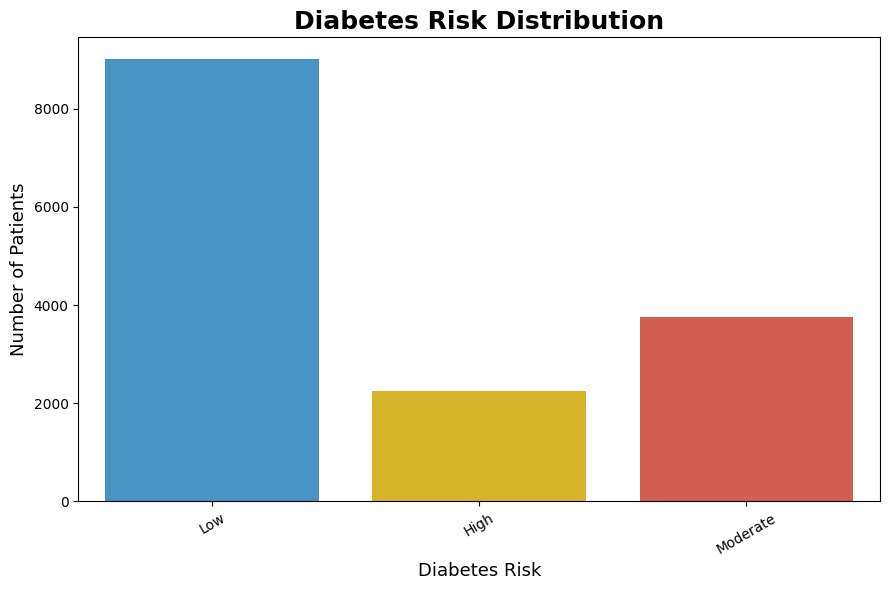

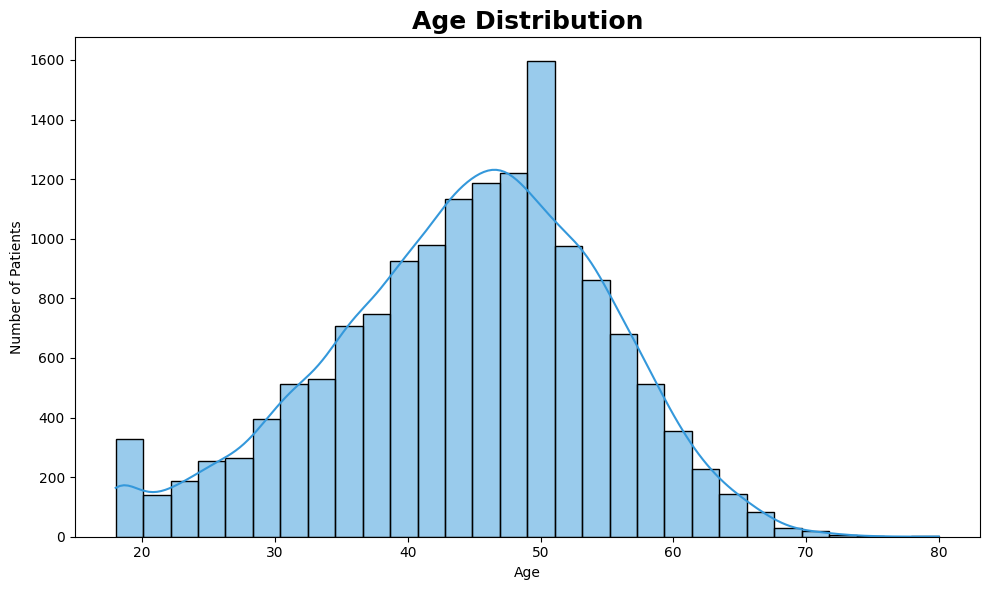

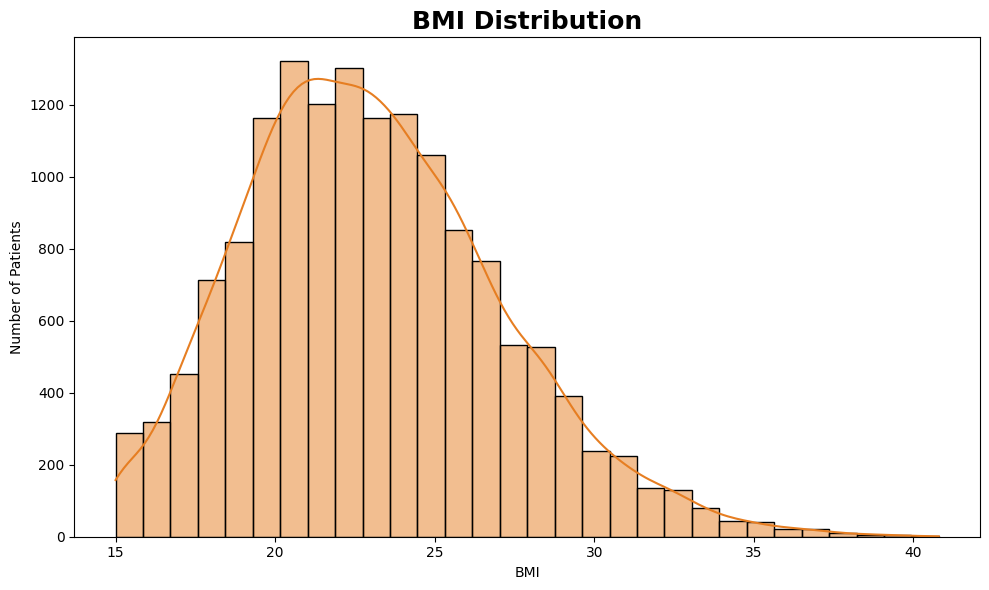

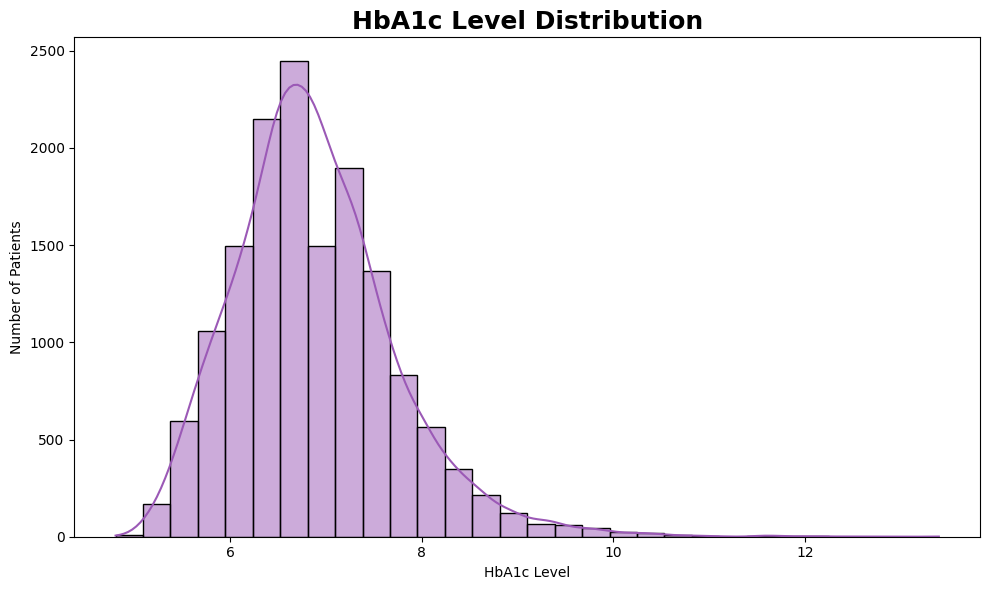

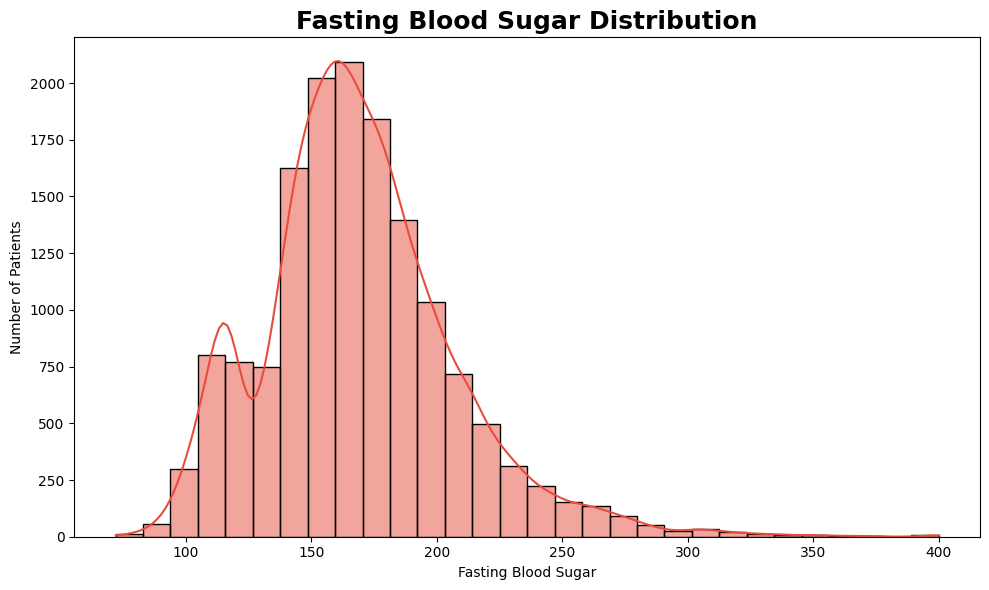

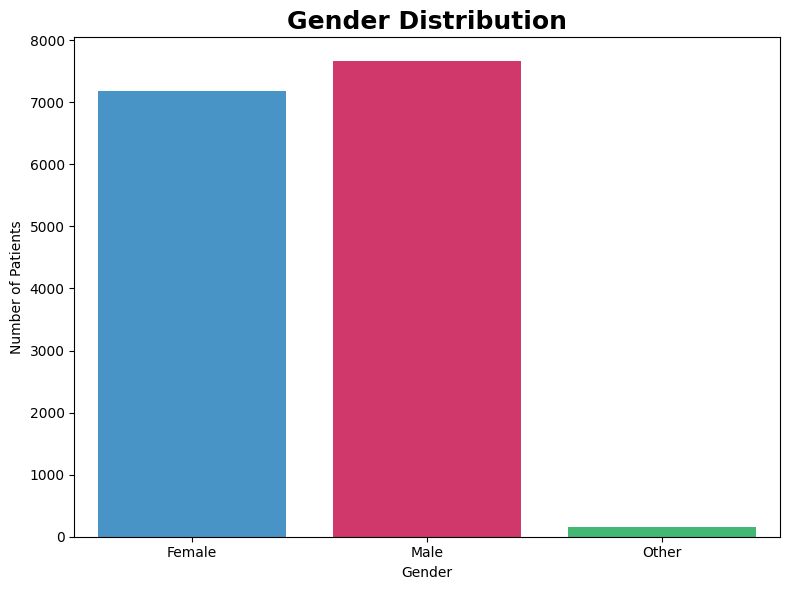

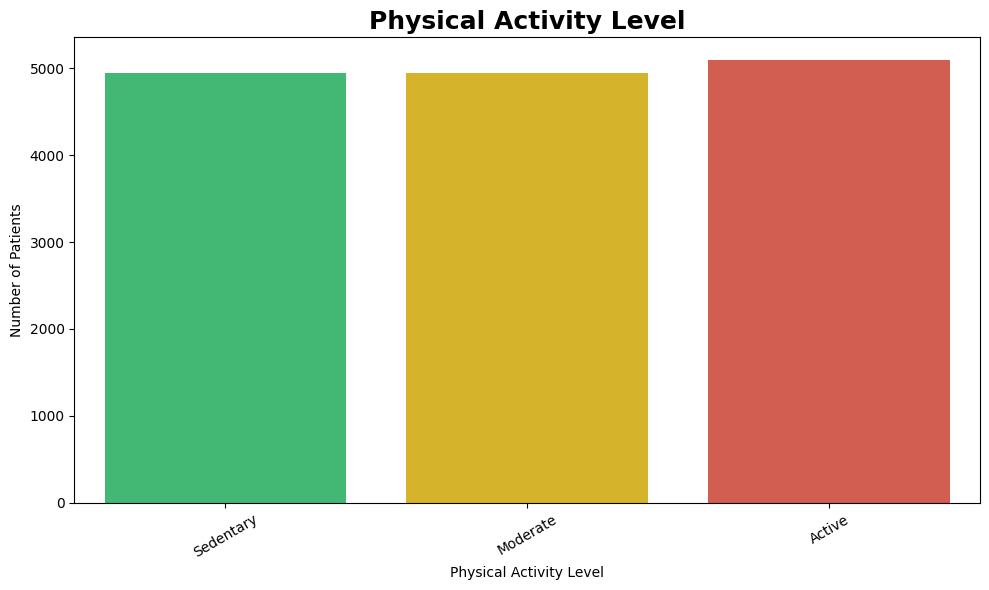

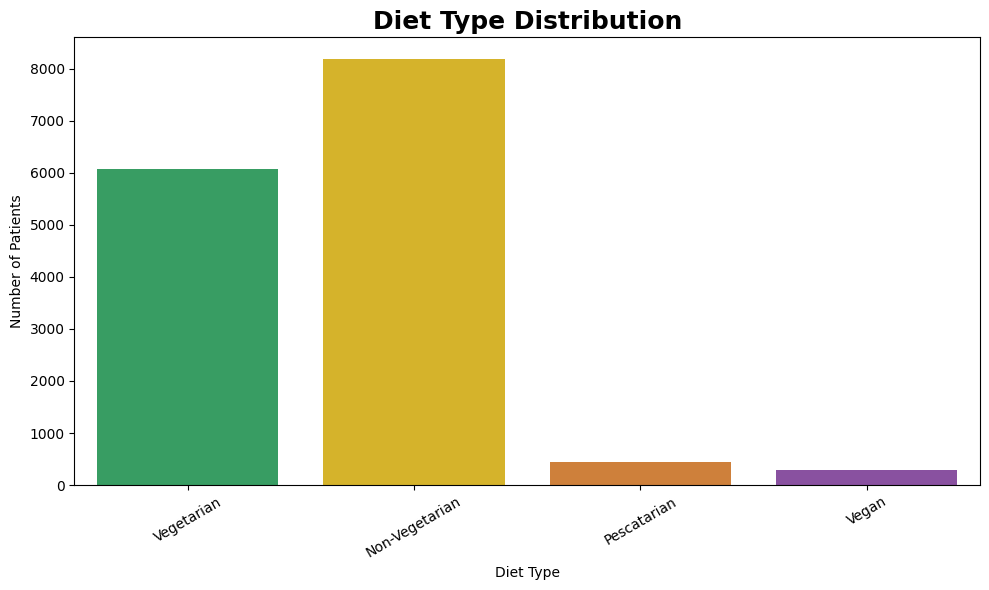

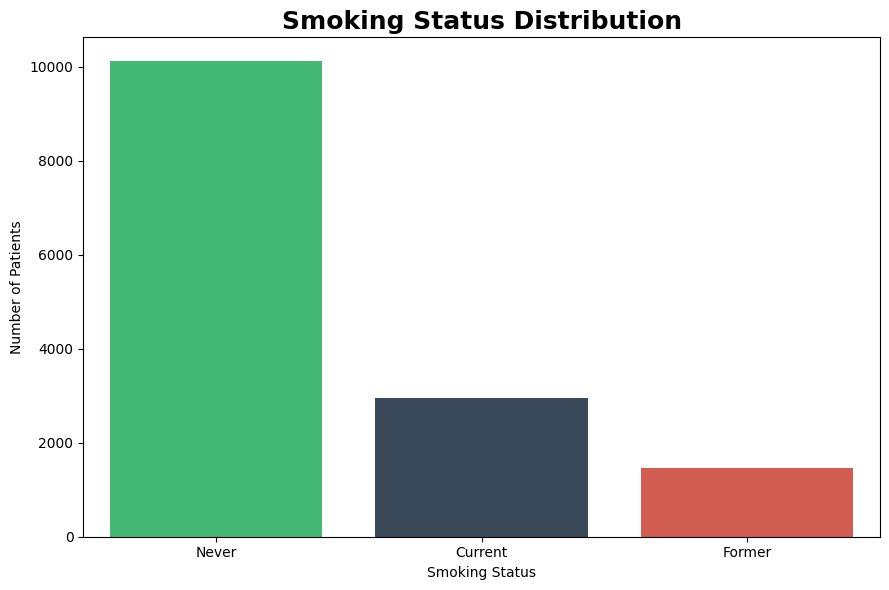

/tmp/ipykernel_16/42618630.py:203: UserWarning: 
The palette list has fewer values (4) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


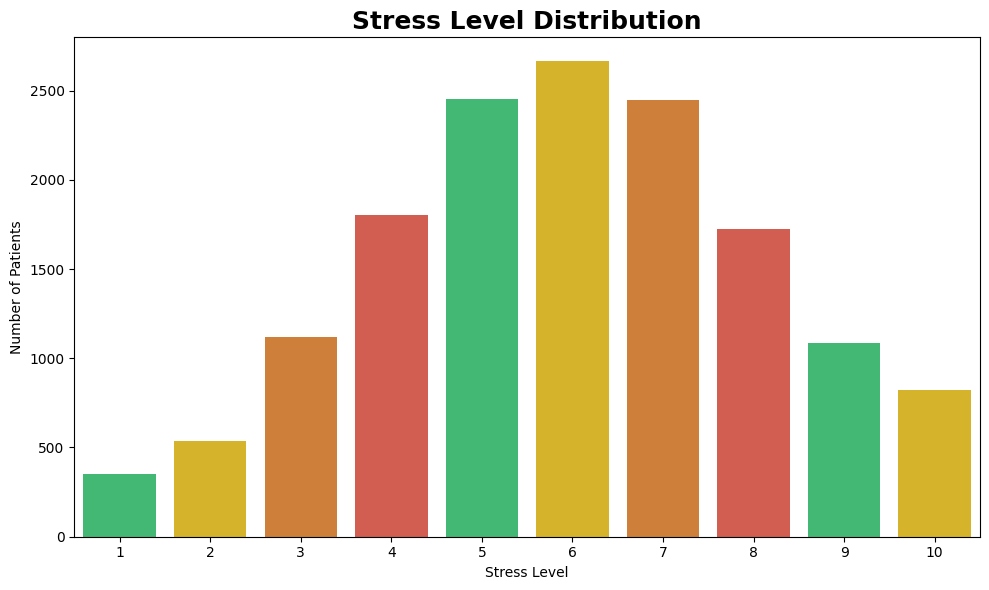

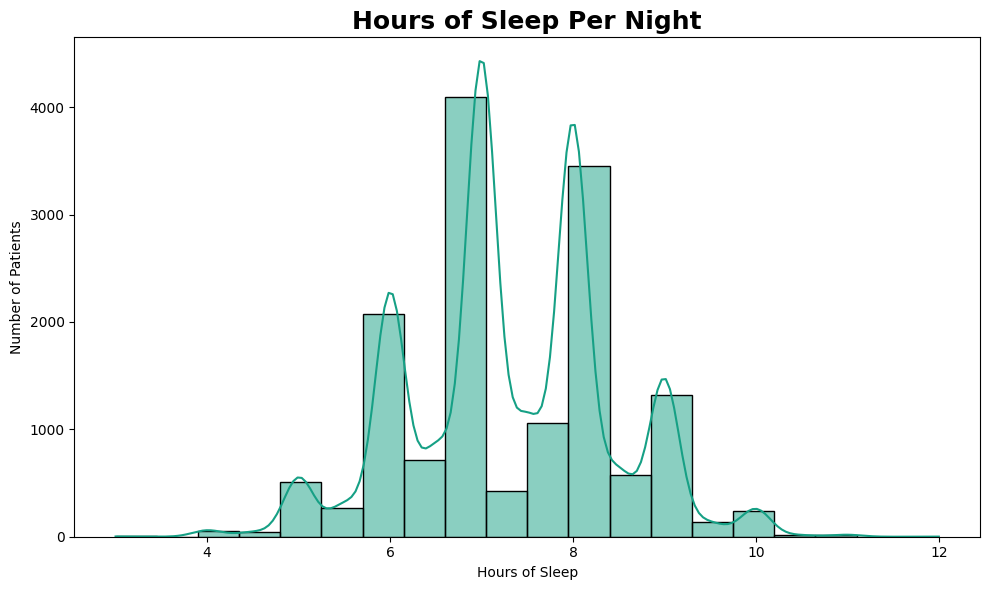

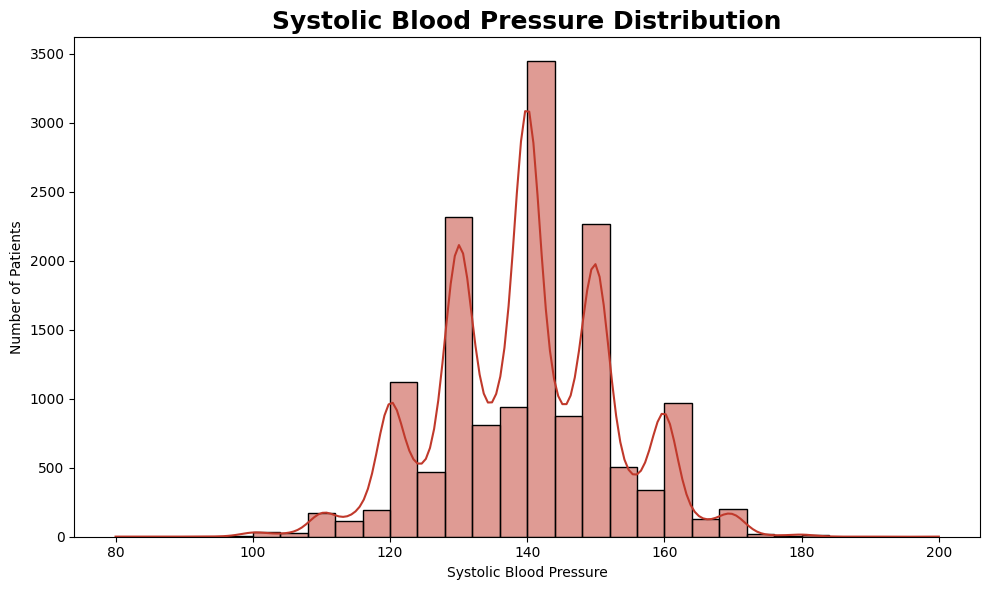

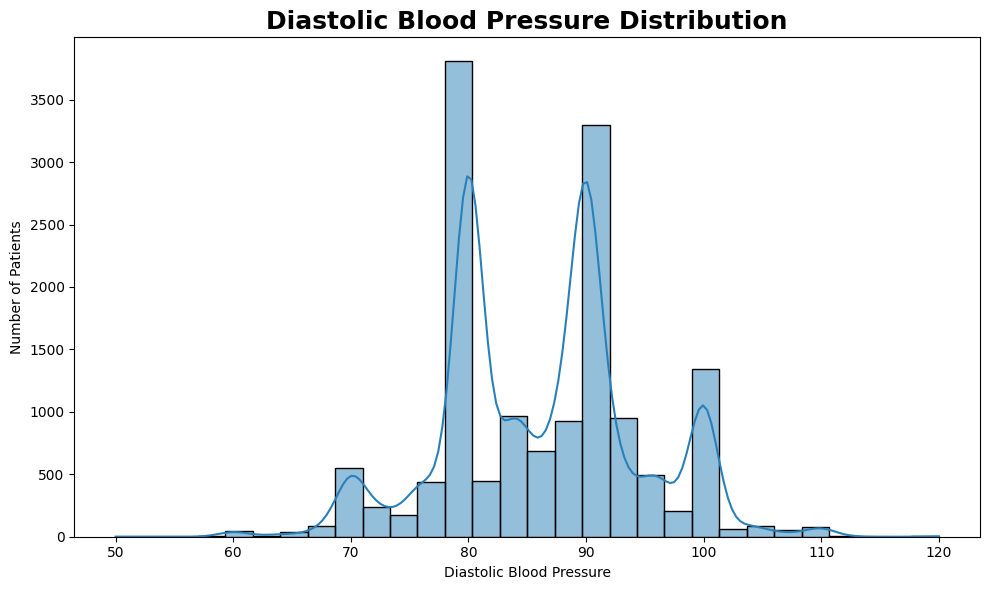

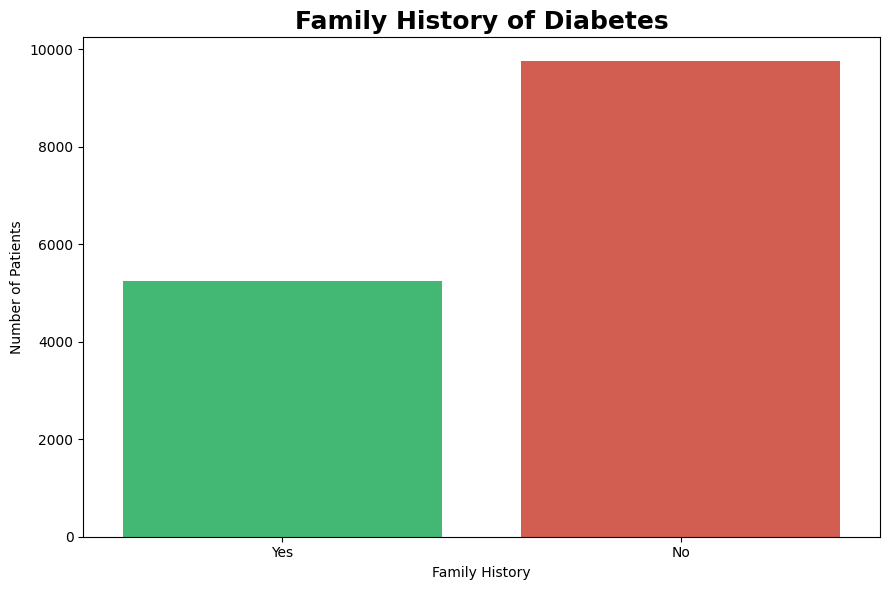

/tmp/ipykernel_16/42618630.py:314: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(


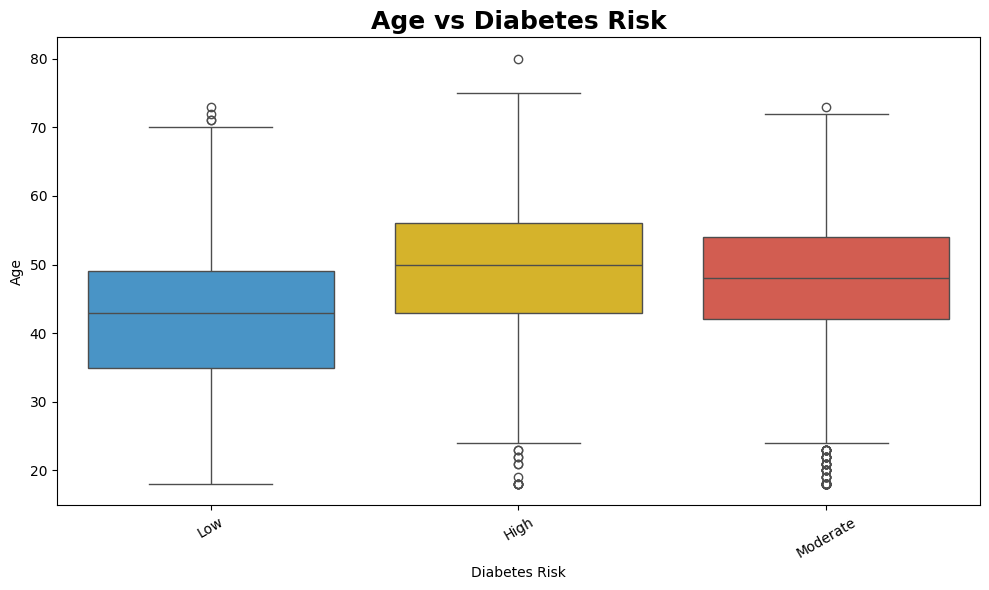

/tmp/ipykernel_16/42618630.py:339: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(


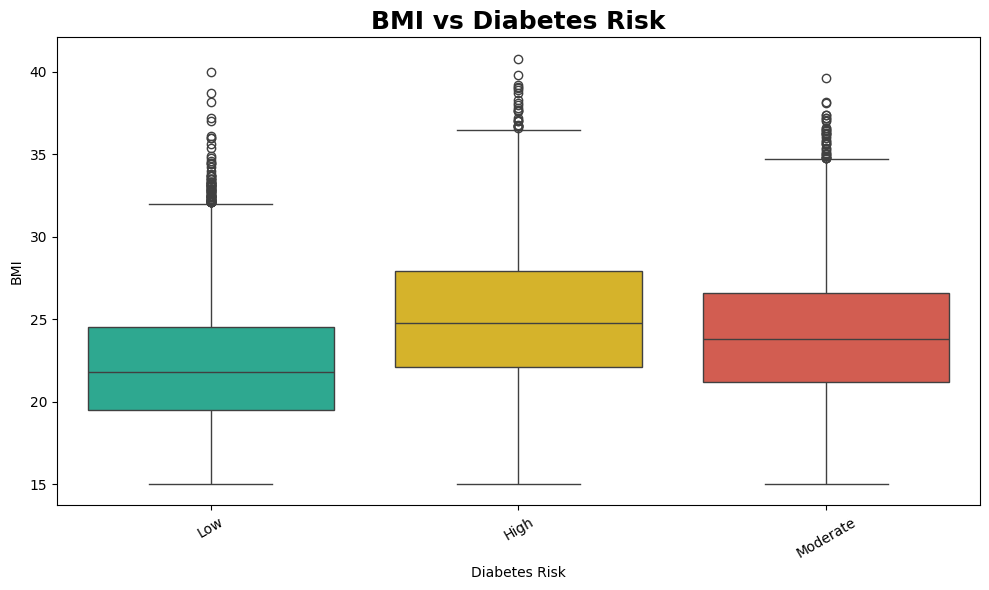

/tmp/ipykernel_16/42618630.py:364: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(


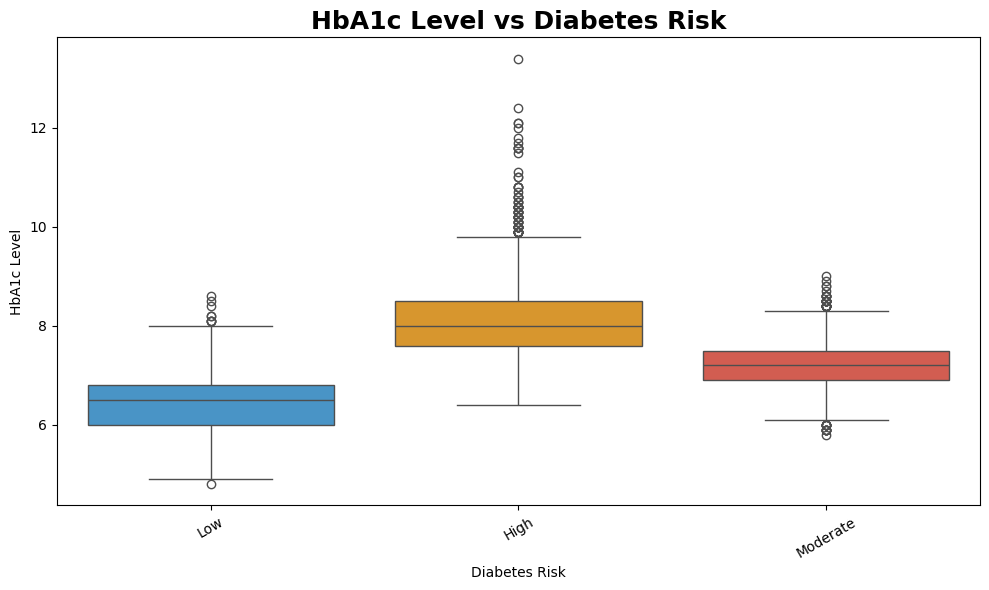

/tmp/ipykernel_16/42618630.py:389: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(


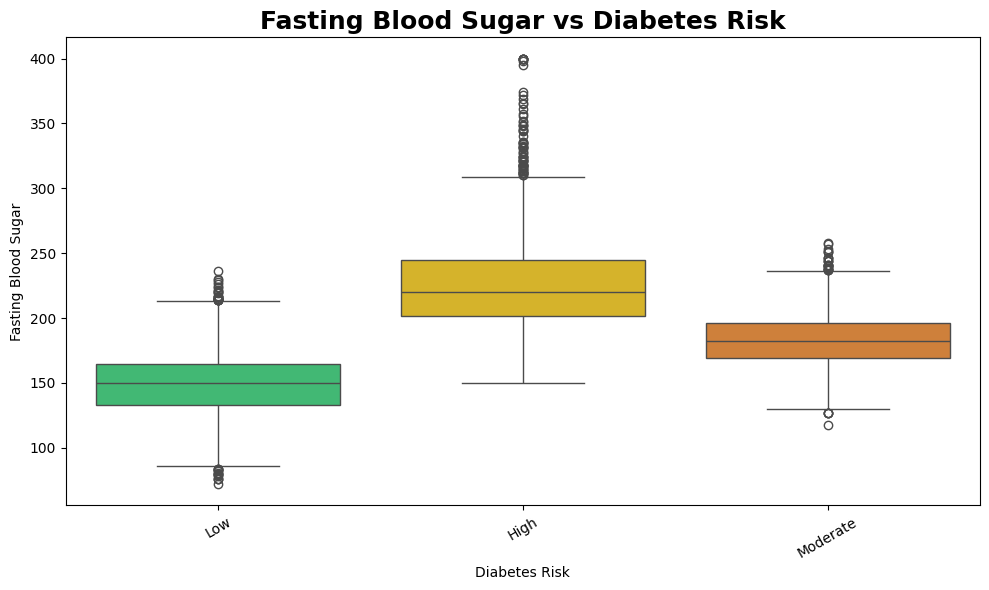

/tmp/ipykernel_16/42618630.py:414: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


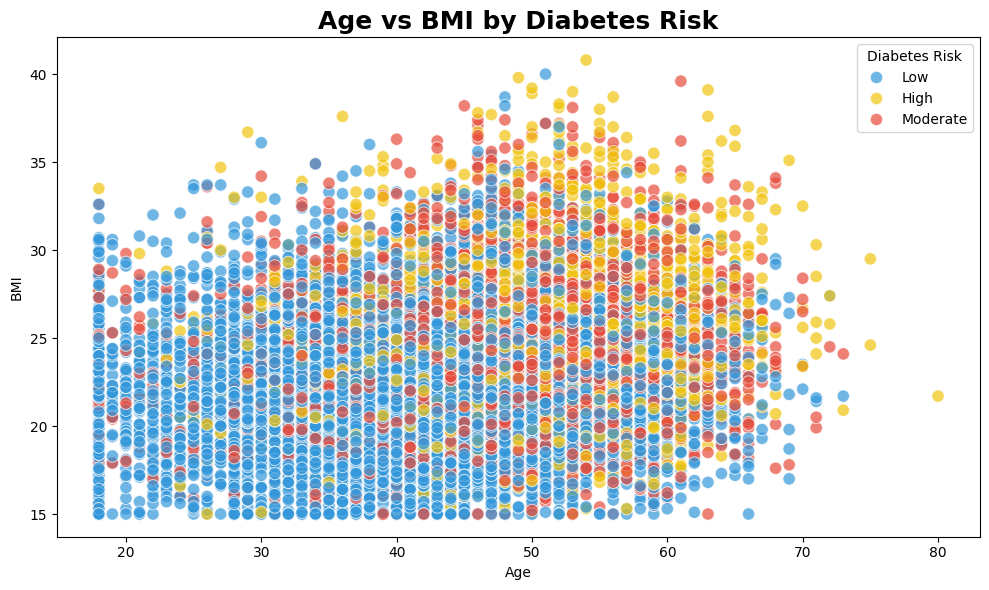

/tmp/ipykernel_16/42618630.py:440: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


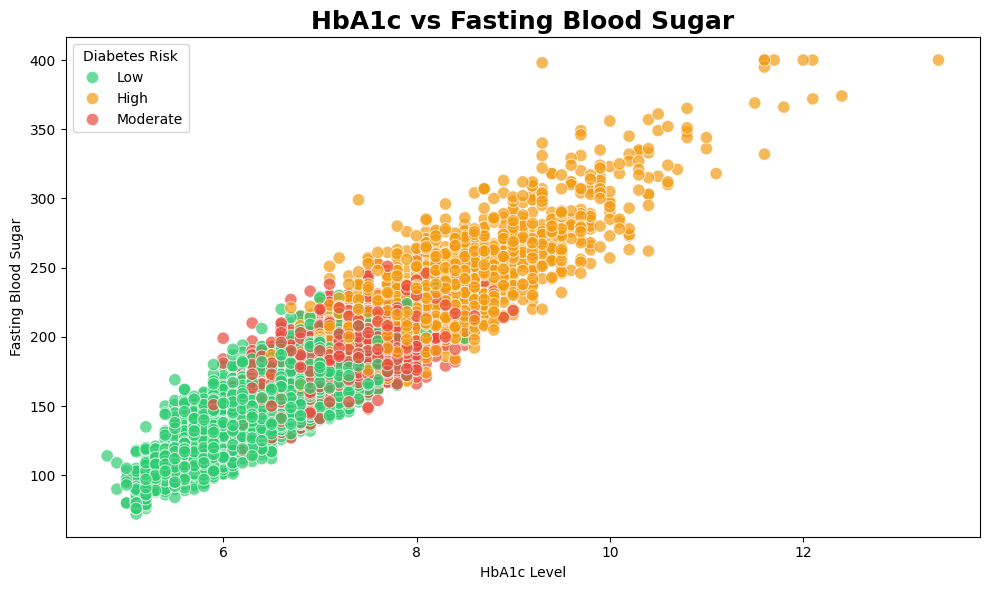

/tmp/ipykernel_16/42618630.py:466: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(


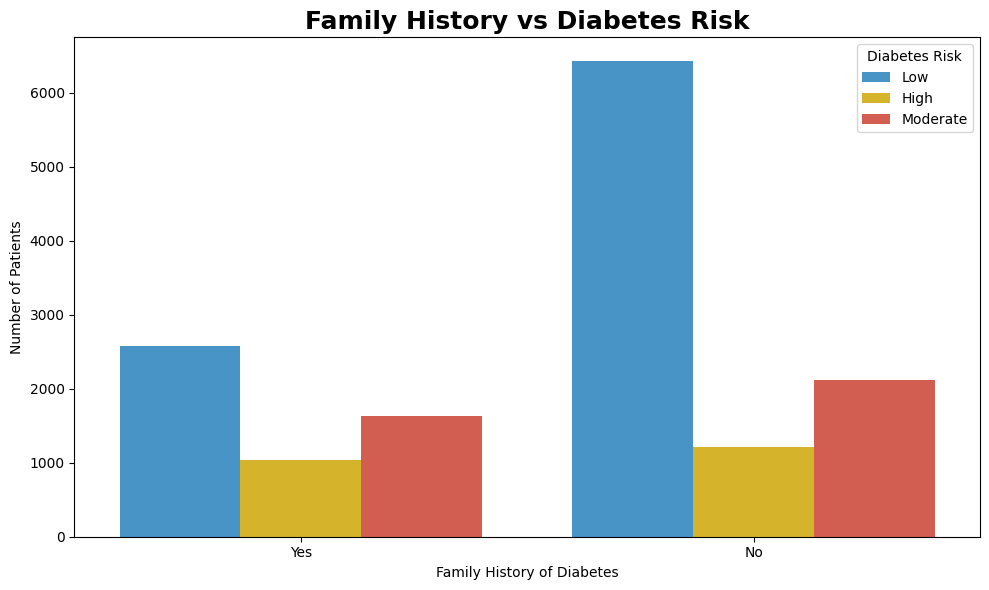

/tmp/ipykernel_16/42618630.py:489: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(


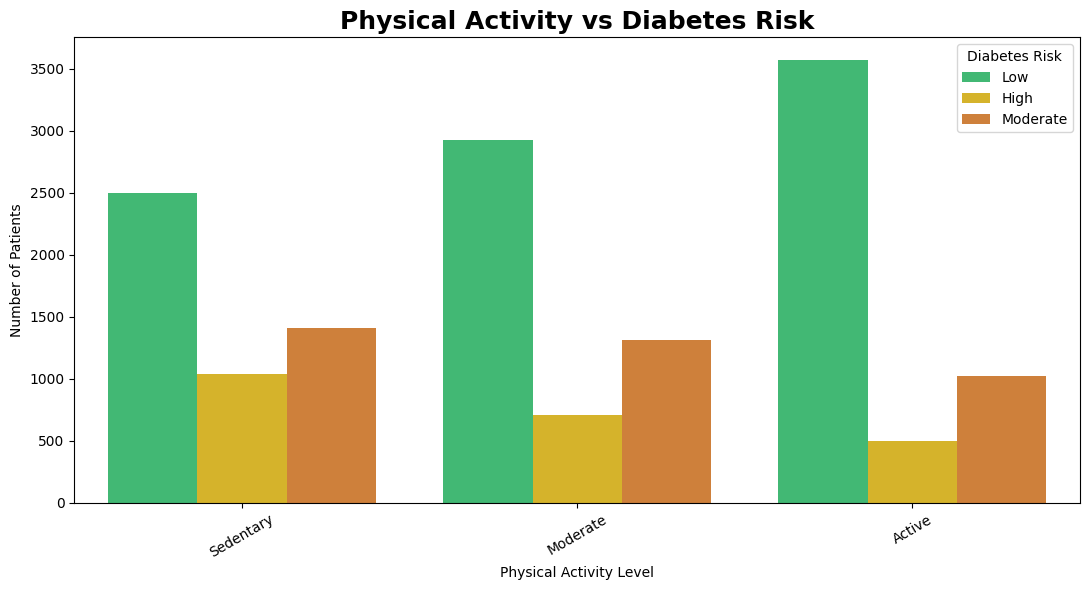

/tmp/ipykernel_16/42618630.py:513: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(


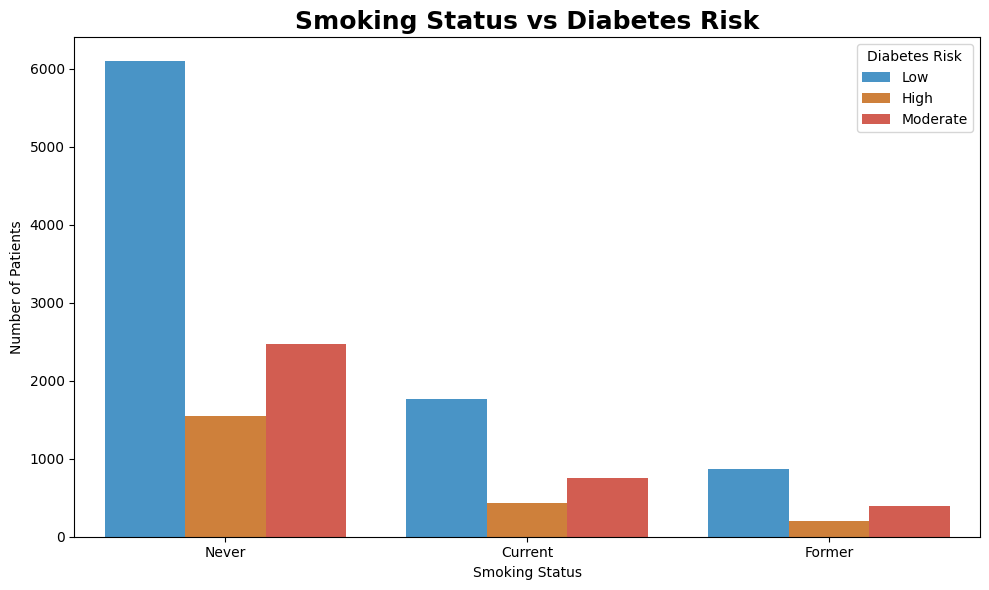

/tmp/ipykernel_16/42618630.py:536: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(


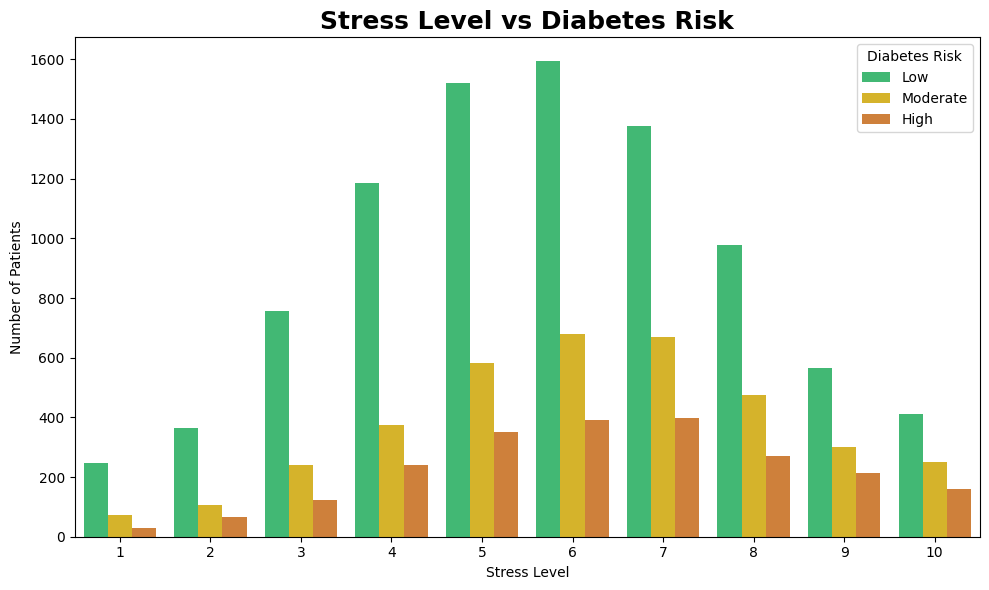

/tmp/ipykernel_16/42618630.py:559: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(


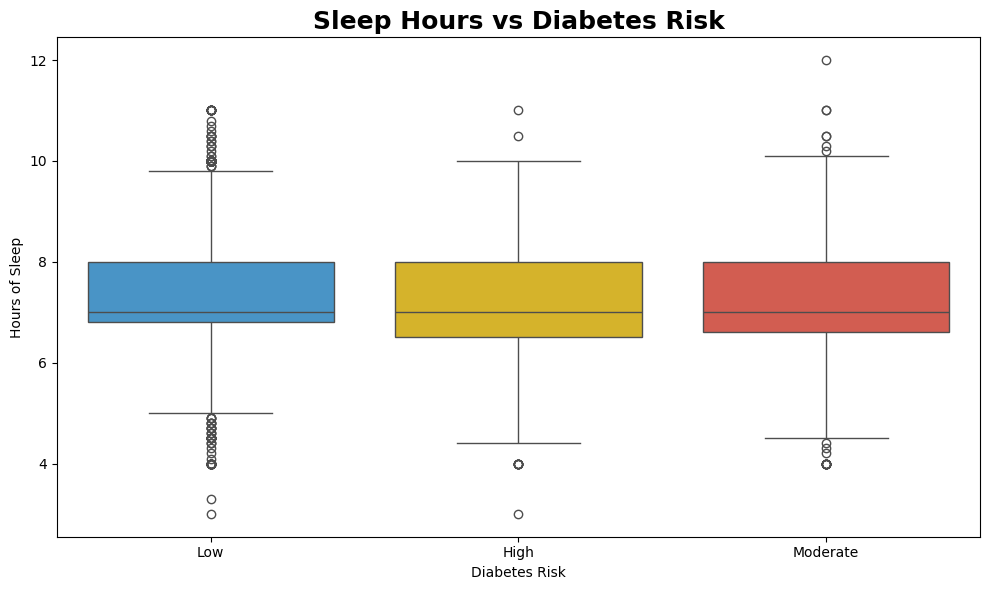

/tmp/ipykernel_16/42618630.py:583: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(


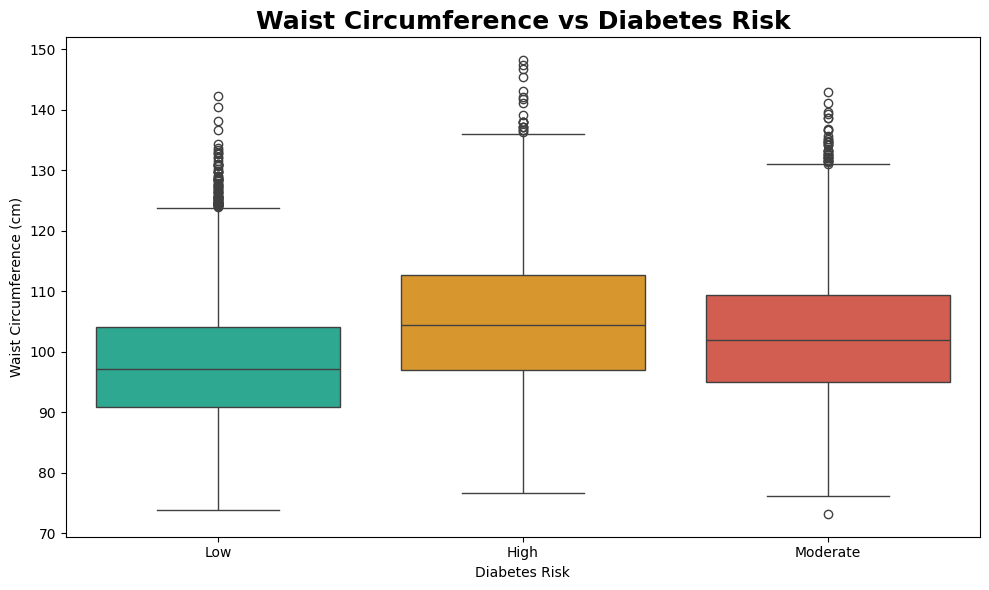

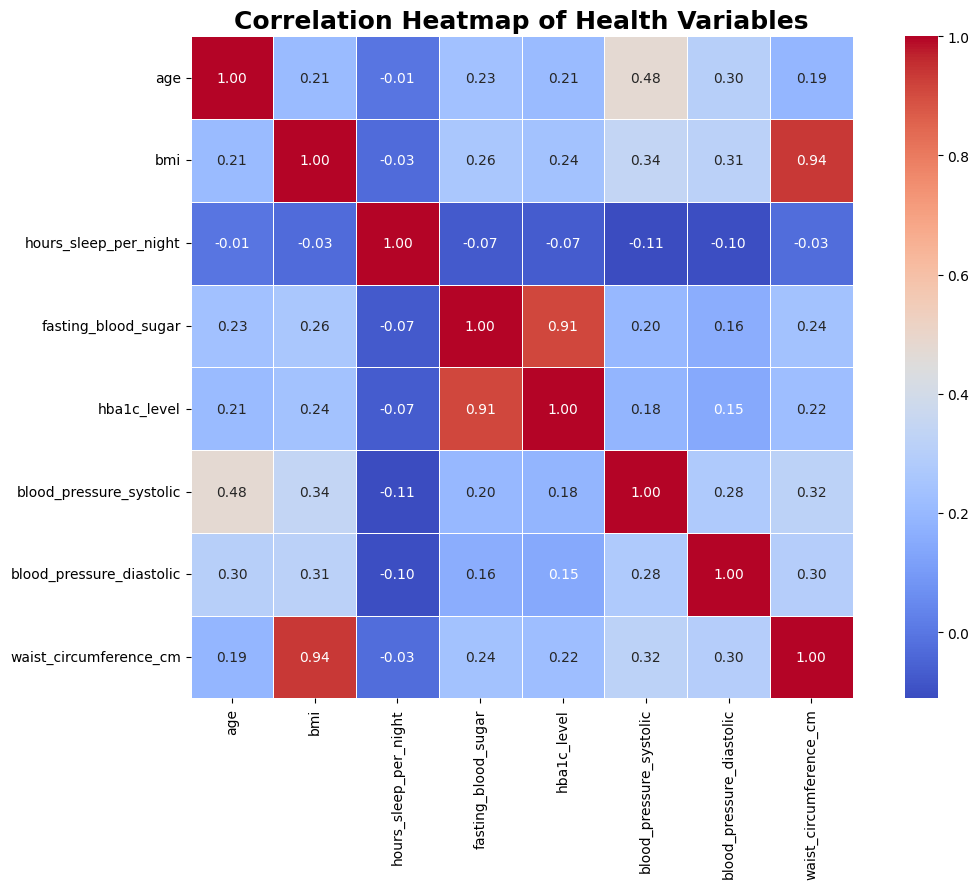

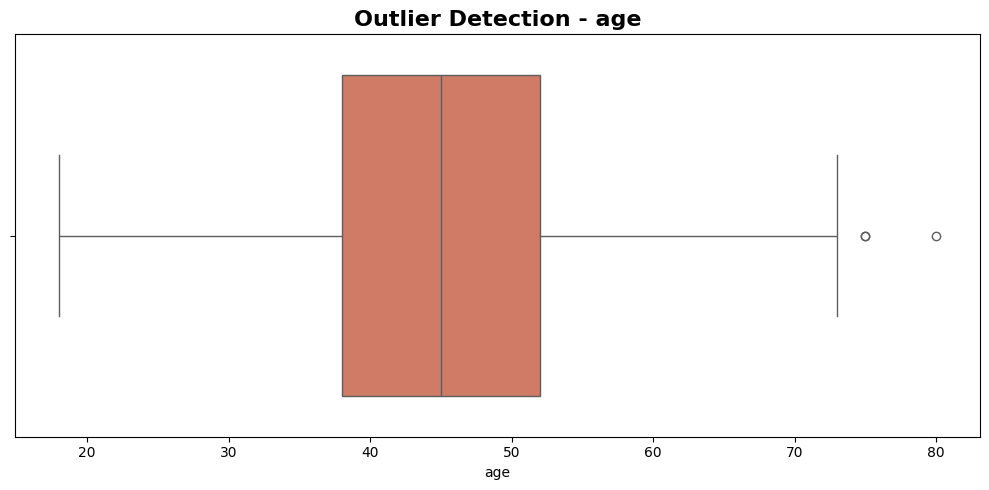

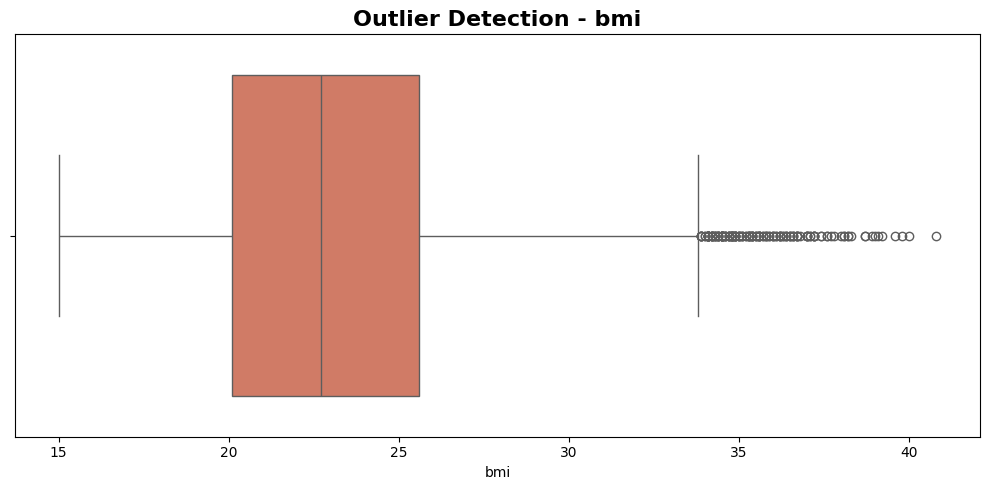

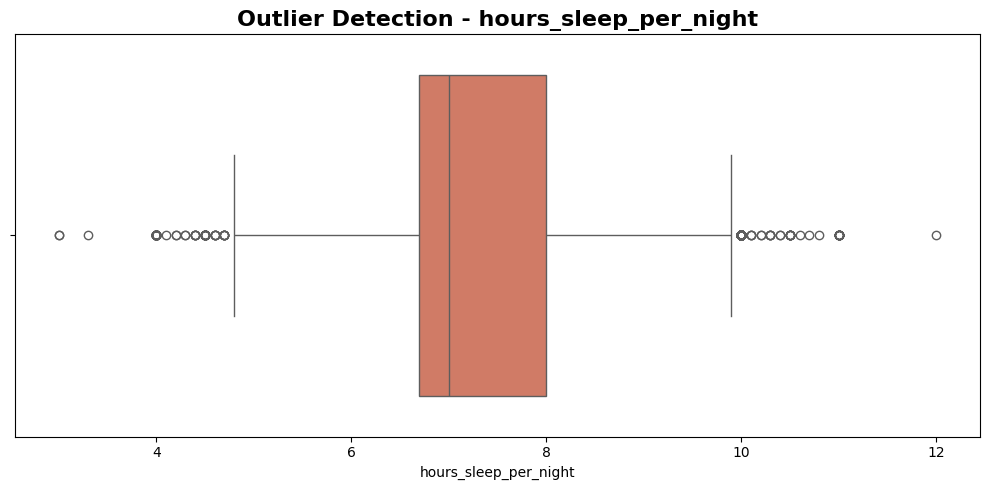

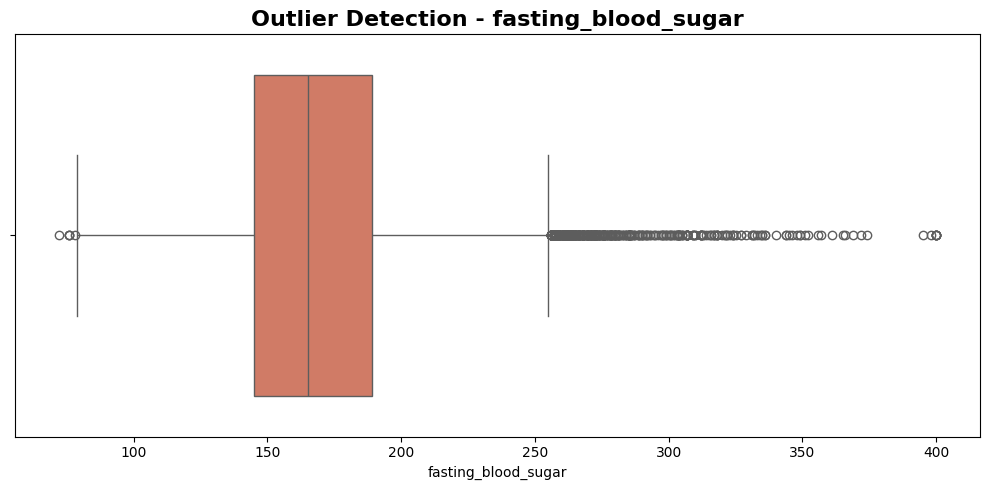

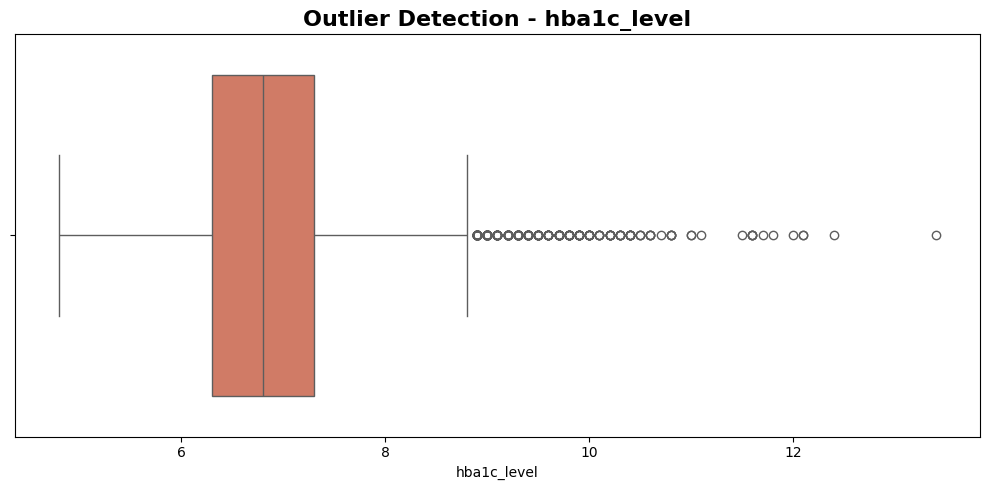

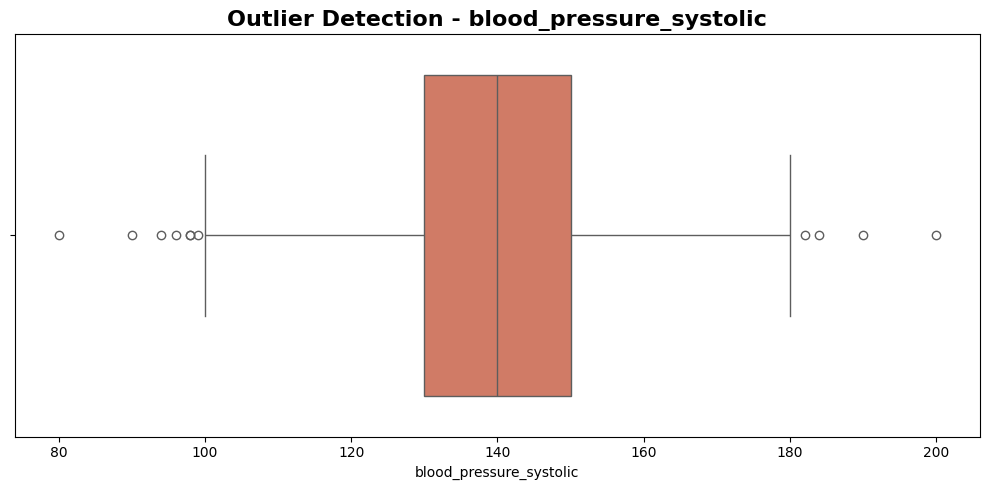

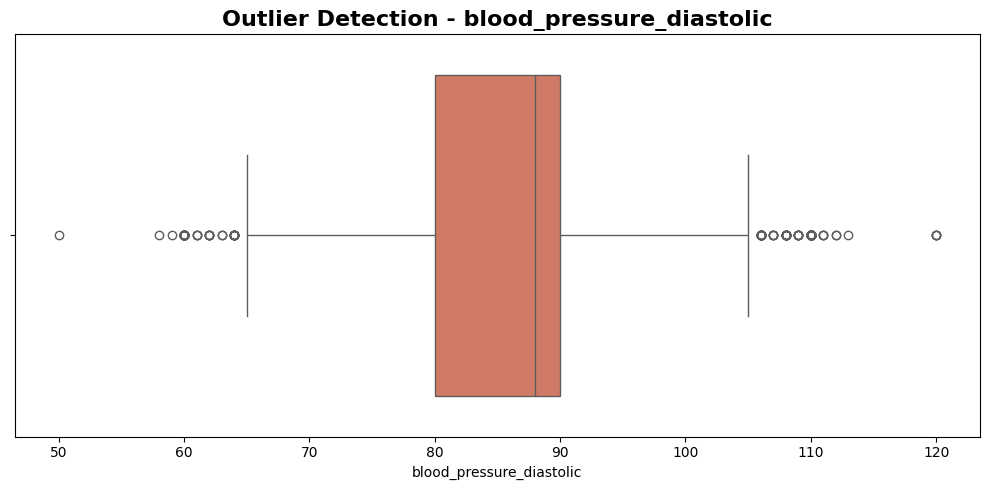

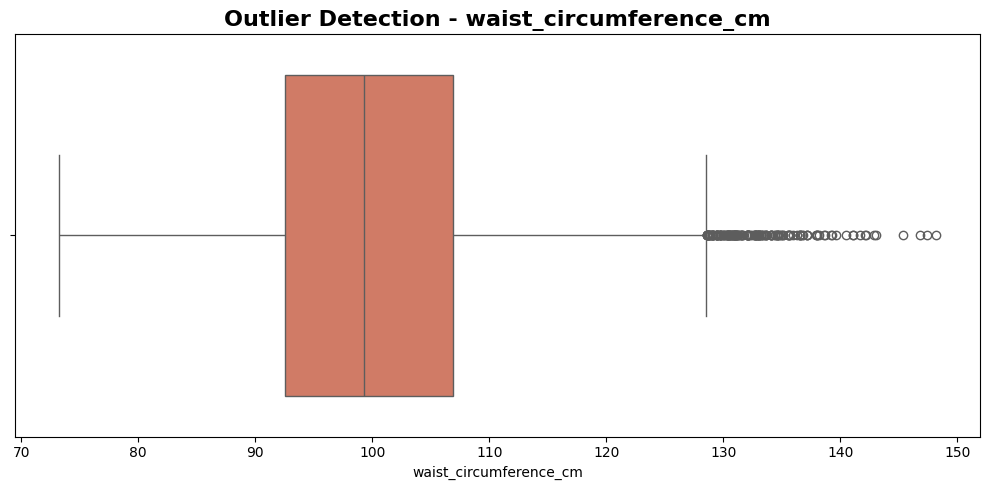


DIABETES DATASET VISUALIZATION COMPLETED

Dataset Shape:
(15000, 19)

Diabetes Risk Counts:
diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64

Gender Counts:
gender
Male      7664
Female    7183
Other      153
Name: count, dtype: int64

Physical Activity Counts:
physical_activity_level
Active       5100
Sedentary    4950
Moderate     4950
Name: count, dtype: int64

Missing Values:
patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracke

In [13]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="diabetes_risk",
    hue="diabetes_risk",
    palette=["#3498DB", "#F1C40F", "#E74C3C", "#9B59B6"],
    legend=False
)

plt.title("Diabetes Risk Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Diabetes Risk", fontsize=13)
plt.ylabel("Number of Patients", fontsize=13)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 4. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    color="#3498DB"
)

plt.title("Age Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 5. BMI DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="bmi",
    bins=30,
    kde=True,
    color="#E67E22"
)

plt.title("BMI Distribution", fontsize=18, fontweight="bold")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 6. HbA1c DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="hba1c_level",
    bins=30,
    kde=True,
    color="#9B59B6"
)

plt.title("HbA1c Level Distribution", fontsize=18, fontweight="bold")
plt.xlabel("HbA1c Level")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 7. FASTING BLOOD SUGAR DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="fasting_blood_sugar",
    bins=30,
    kde=True,
    color="#E74C3C"
)

plt.title("Fasting Blood Sugar Distribution",
          fontsize=18, fontweight="bold")

plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 8. GENDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="gender",
    hue="gender",
    palette=["#3498DB", "#E91E63", "#2ECC71"],
    legend=False
)

plt.title("Gender Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 9. PHYSICAL ACTIVITY LEVEL
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="physical_activity_level",
    hue="physical_activity_level",
    palette=["#2ECC71", "#F1C40F", "#E74C3C"],
    legend=False
)

plt.title("Physical Activity Level",
          fontsize=18, fontweight="bold")

plt.xlabel("Physical Activity Level")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 10. DIET TYPE
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="diet_type",
    hue="diet_type",
    palette=["#27AE60", "#F1C40F", "#E67E22", "#8E44AD"],
    legend=False
)

plt.title("Diet Type Distribution",
          fontsize=18, fontweight="bold")

plt.xlabel("Diet Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 11. SMOKING STATUS
# ============================================================

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="smoking_status",
    hue="smoking_status",
    palette=["#2ECC71", "#34495E", "#E74C3C"],
    legend=False
)

plt.title("Smoking Status Distribution",
          fontsize=18, fontweight="bold")

plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 12. STRESS LEVEL
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="stress_level",
    hue="stress_level",
    palette=["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C"],
    legend=False
)

plt.title("Stress Level Distribution",
          fontsize=18, fontweight="bold")

plt.xlabel("Stress Level")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 13. SLEEP HOURS
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="hours_sleep_per_night",
    bins=20,
    kde=True,
    color="#16A085"
)

plt.title("Hours of Sleep Per Night",
          fontsize=18, fontweight="bold")

plt.xlabel("Hours of Sleep")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 14. BLOOD PRESSURE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="blood_pressure_systolic",
    bins=30,
    kde=True,
    color="#C0392B"
)

plt.title("Systolic Blood Pressure Distribution",
          fontsize=18, fontweight="bold")

plt.xlabel("Systolic Blood Pressure")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="blood_pressure_diastolic",
    bins=30,
    kde=True,
    color="#2980B9"
)

plt.title("Diastolic Blood Pressure Distribution",
          fontsize=18, fontweight="bold")

plt.xlabel("Diastolic Blood Pressure")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 15. FAMILY HISTORY OF DIABETES
# ============================================================

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="family_history_diabetes",
    hue="family_history_diabetes",
    palette=["#2ECC71", "#E74C3C"],
    legend=False
)

plt.title("Family History of Diabetes",
          fontsize=18, fontweight="bold")

plt.xlabel("Family History")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 16. AGE VS DIABETES RISK
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="diabetes_risk",
    y="age",
    hue="diabetes_risk",
    palette=["#3498DB", "#F1C40F", "#E74C3C", "#9B59B6"],
    legend=False
)

plt.title("Age vs Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Diabetes Risk")
plt.ylabel("Age")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 17. BMI VS DIABETES RISK
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="diabetes_risk",
    y="bmi",
    hue="diabetes_risk",
    palette=["#1ABC9C", "#F1C40F", "#E74C3C", "#8E44AD"],
    legend=False
)

plt.title("BMI vs Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Diabetes Risk")
plt.ylabel("BMI")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 18. HbA1c VS DIABETES RISK
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="diabetes_risk",
    y="hba1c_level",
    hue="diabetes_risk",
    palette=["#3498DB", "#F39C12", "#E74C3C", "#9B59B6"],
    legend=False
)

plt.title("HbA1c Level vs Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Diabetes Risk")
plt.ylabel("HbA1c Level")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 19. FASTING BLOOD SUGAR VS DIABETES RISK
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="diabetes_risk",
    y="fasting_blood_sugar",
    hue="diabetes_risk",
    palette=["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C"],
    legend=False
)

plt.title("Fasting Blood Sugar vs Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Diabetes Risk")
plt.ylabel("Fasting Blood Sugar")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 20. AGE VS BMI
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="bmi",
    hue="diabetes_risk",
    palette=["#3498DB", "#F1C40F", "#E74C3C", "#9B59B6"],
    s=80,
    alpha=0.7
)

plt.title("Age vs BMI by Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Age")
plt.ylabel("BMI")
plt.legend(title="Diabetes Risk")
plt.tight_layout()
plt.show()


# ============================================================
# 21. HbA1c VS FASTING BLOOD SUGAR
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="hba1c_level",
    y="fasting_blood_sugar",
    hue="diabetes_risk",
    palette=["#2ECC71", "#F39C12", "#E74C3C", "#8E44AD"],
    s=80,
    alpha=0.7
)

plt.title("HbA1c vs Fasting Blood Sugar",
          fontsize=18, fontweight="bold")

plt.xlabel("HbA1c Level")
plt.ylabel("Fasting Blood Sugar")
plt.legend(title="Diabetes Risk")
plt.tight_layout()
plt.show()


# ============================================================
# 22. FAMILY HISTORY VS DIABETES RISK
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="family_history_diabetes",
    hue="diabetes_risk",
    palette=["#3498DB", "#F1C40F", "#E74C3C", "#9B59B6"]
)

plt.title("Family History vs Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Family History of Diabetes")
plt.ylabel("Number of Patients")
plt.legend(title="Diabetes Risk")
plt.tight_layout()
plt.show()


# ============================================================
# 23. PHYSICAL ACTIVITY VS DIABETES RISK
# ============================================================

plt.figure(figsize=(11, 6))

sns.countplot(
    data=df,
    x="physical_activity_level",
    hue="diabetes_risk",
    palette=["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C"]
)

plt.title("Physical Activity vs Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Physical Activity Level")
plt.ylabel("Number of Patients")
plt.legend(title="Diabetes Risk")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 24. SMOKING VS DIABETES RISK
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="smoking_status",
    hue="diabetes_risk",
    palette=["#3498DB", "#E67E22", "#E74C3C", "#9B59B6"]
)

plt.title("Smoking Status vs Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")
plt.legend(title="Diabetes Risk")
plt.tight_layout()
plt.show()


# ============================================================
# 25. STRESS VS DIABETES RISK
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="stress_level",
    hue="diabetes_risk",
    palette=["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C"]
)

plt.title("Stress Level vs Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Stress Level")
plt.ylabel("Number of Patients")
plt.legend(title="Diabetes Risk")
plt.tight_layout()
plt.show()


# ============================================================
# 26. SLEEP VS DIABETES RISK
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="diabetes_risk",
    y="hours_sleep_per_night",
    hue="diabetes_risk",
    palette=["#3498DB", "#F1C40F", "#E74C3C", "#9B59B6"],
    legend=False
)

plt.title("Sleep Hours vs Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Diabetes Risk")
plt.ylabel("Hours of Sleep")
plt.tight_layout()
plt.show()


# ============================================================
# 27. WAIST CIRCUMFERENCE VS DIABETES RISK
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="diabetes_risk",
    y="waist_circumference_cm",
    hue="diabetes_risk",
    palette=["#1ABC9C", "#F39C12", "#E74C3C", "#8E44AD"],
    legend=False
)

plt.title("Waist Circumference vs Diabetes Risk",
          fontsize=18, fontweight="bold")

plt.xlabel("Diabetes Risk")
plt.ylabel("Waist Circumference (cm)")
plt.tight_layout()
plt.show()


# ============================================================
# 28. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "age",
    "bmi",
    "hours_sleep_per_night",
    "fasting_blood_sugar",
    "hba1c_level",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "waist_circumference_cm"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap of Health Variables",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 29. OUTLIER DETECTION
# ============================================================

for column in numeric_columns:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=df[column],
        color="#E17055"
    )

    plt.title(
        f"Outlier Detection - {column}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(column)

    plt.tight_layout()
    plt.show()


# ============================================================
# 30. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("DIABETES DATASET VISUALIZATION COMPLETED")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nDiabetes Risk Counts:")
print(df["diabetes_risk"].value_counts())

print("\nGender Counts:")
print(df["gender"].value_counts())

print("\nPhysical Activity Counts:")
print(df["physical_activity_level"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

## Feature engineering

In [14]:
# Basic data inspection
print('Columns and their data types:')
print(df.dtypes)

# Check for missing values
print('\nMissing values in each column:')
print(df.isnull().sum())

# For this example, we assume the data is well-formed. In other cases, one might need to handle missing values or incorrect types.

# Optionally drop columns that are not useful for modeling. For instance, 'patient_id' is likely an identifier.
df_clean = df.drop(columns=['patient_id'], errors='ignore')

# Display first few rows after cleaning
print('\nPreview of cleaned data:')
print(df_clean.head())

Columns and their data types:
patient_id                    int64
age                           int64
gender                       object
city                         object
bmi                         float64
family_history_diabetes      object
physical_activity_level      object
diet_type                    object
smoking_status               object
alcohol_consumption          object
hours_sleep_per_night       float64
stress_level                  int64
fasting_blood_sugar           int64
hba1c_level                 float64
blood_pressure_systolic       int64
blood_pressure_diastolic      int64
waist_circumference_cm      float64
income_bracket               object
diabetes_risk                object
dtype: object

Missing values in each column:
patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type

DIABETES RISK PREDICTION

Dataset Shape:
(15000, 18)

Dataset Columns:
['age', 'gender', 'city', 'bmi', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket', 'diabetes_risk']

Feature Shape: (15000, 17)
Target Shape: (15000,)

Target Classes:
diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64

Target Class Names:
['Low' 'High' 'Moderate']

Encoded Target Classes:
High = 0
Low = 1
Moderate = 2

Numerical Features:
['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']

Categorical Features:
['gender', 'city', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_

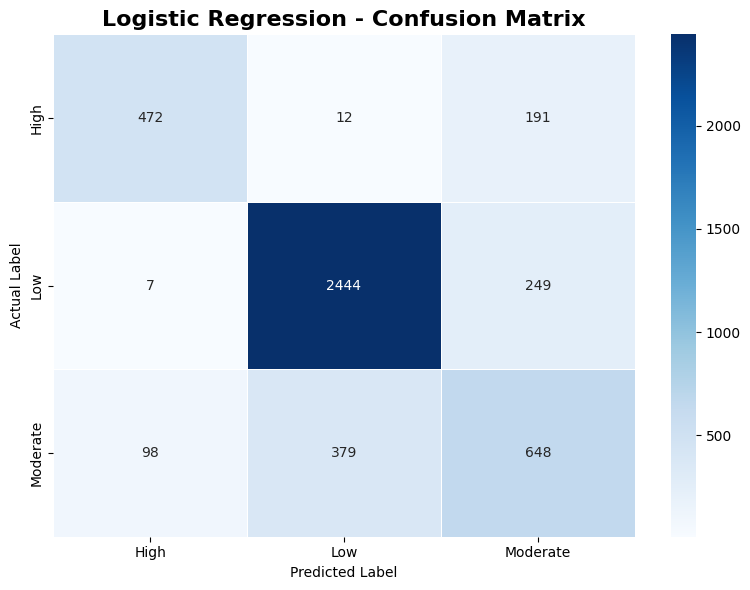


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       0.82      0.70      0.75       675
         Low       0.86      0.91      0.88      2700
    Moderate       0.60      0.58      0.59      1125

    accuracy                           0.79      4500
   macro avg       0.76      0.73      0.74      4500
weighted avg       0.79      0.79      0.79      4500


Actual vs Predicted:
      Actual Predicted
0        Low       Low
1        Low  Moderate
2   Moderate  Moderate
3        Low  Moderate
4        Low       Low
5   Moderate  Moderate
6        Low       Low
7        Low       Low
8        Low       Low
9        Low       Low
10       Low  Moderate
11  Moderate       Low
12  Moderate       Low
13       Low       Low
14       Low       Low
15      High      High
16      High      High
17       Low       Low
18       Low       Low
19       Low       Low


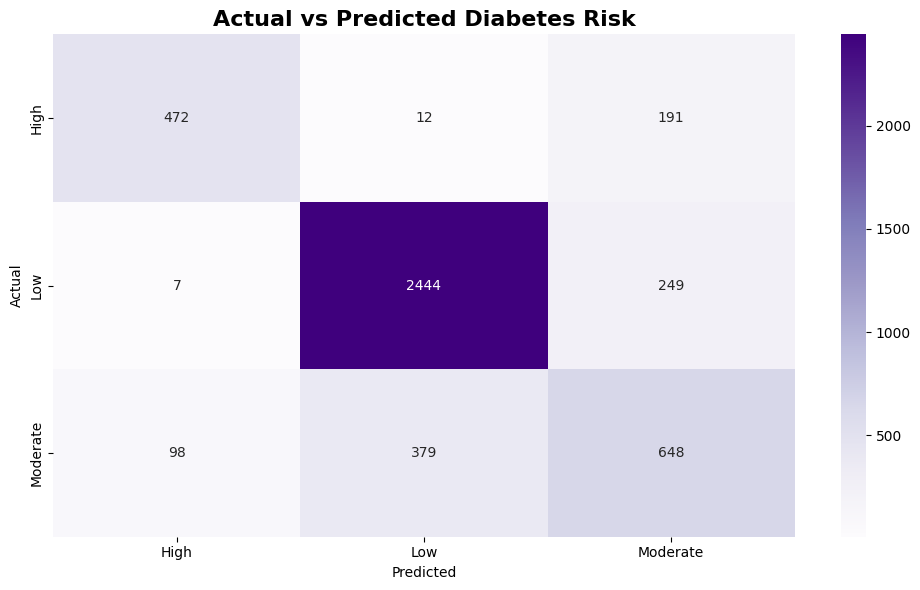


TOP 20 IMPORTANT FEATURES
                                           Feature  Importance
4                     numeric__fasting_blood_sugar    1.247239
5                             numeric__hba1c_level    0.981846
0                                     numeric__age    0.464838
28        categorical__family_history_diabetes_Yes    0.352508
1                                     numeric__bmi    0.329470
19                       categorical__city_Kolkata    0.279080
18                        categorical__city_Kanpur    0.276227
10                       categorical__gender_Other    0.184393
20                       categorical__city_Lucknow    0.181255
11                     categorical__city_Bengaluru    0.180762
21                        categorical__city_Mumbai    0.166436
31              categorical__diet_type_Pescatarian    0.152558
22                        categorical__city_Nagpur    0.143738
16                        categorical__city_Indore    0.143581
29   categorical__physical_a

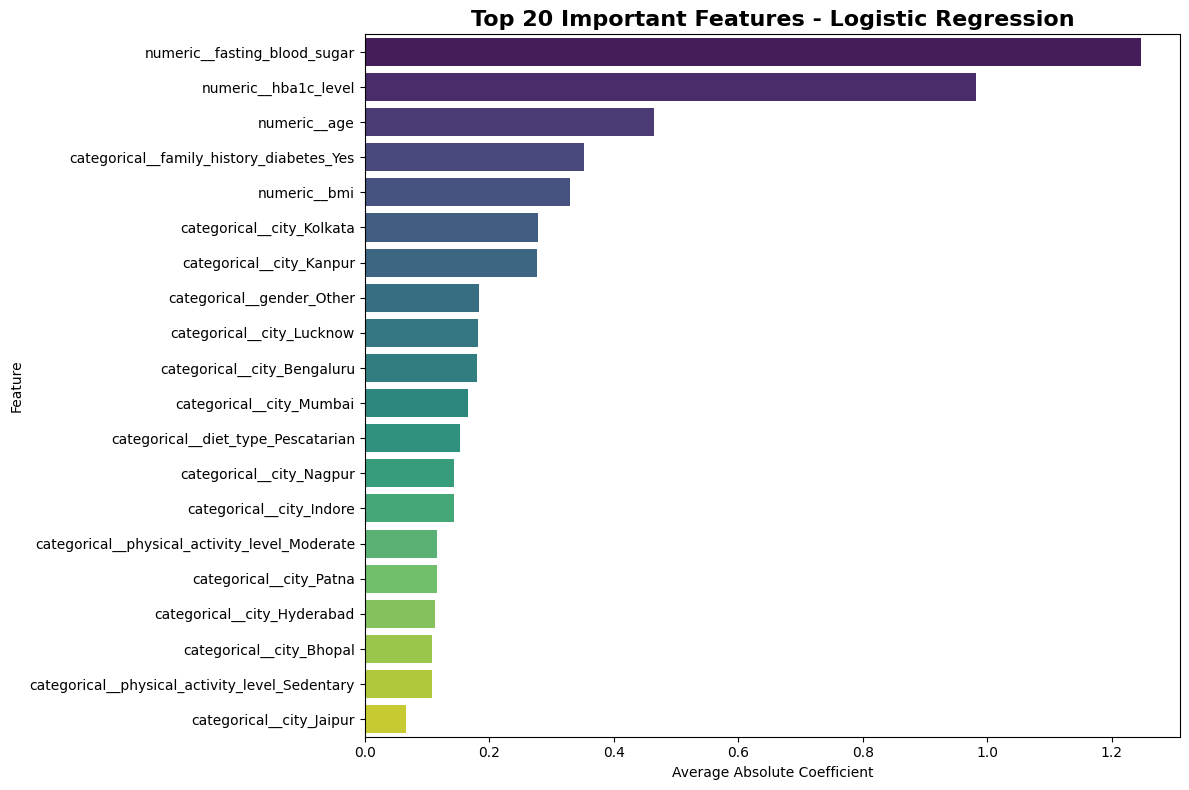


FINAL MODEL SUMMARY
Algorithm       : Logistic Regression
Training Samples: 10500
Testing Samples : 4500
Features        : 17
Accuracy        : 79.20%
Precision       : 78.88%
Recall          : 79.20%
F1 Score        : 78.94%

Model completed successfully!


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)


# ------------------------------------------------------------
# 2. DATASET
# ------------------------------------------------------------

# If df_clean already exists, this line is not required.
# Otherwise use:
#
# df_clean = pd.read_csv("diabetes_risk.csv")

print("=" * 70)
print("DIABETES RISK PREDICTION")
print("=" * 70)

print("\nDataset Shape:")
print(df_clean.shape)

print("\nDataset Columns:")
print(df_clean.columns.tolist())


# ------------------------------------------------------------
# 3. REMOVE UNNECESSARY ID COLUMN
# ------------------------------------------------------------

# patient_id is an identifier and normally should not be
# used as a predictive feature.

if "patient_id" in df_clean.columns:
    df_clean = df_clean.drop(columns=["patient_id"])


# ------------------------------------------------------------
# 4. DEFINE TARGET AND FEATURES
# ------------------------------------------------------------

target = "diabetes_risk"

X = df_clean.drop(columns=[target])
y = df_clean[target]


print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


# ------------------------------------------------------------
# 5. CHECK TARGET CLASSES
# ------------------------------------------------------------

print("\nTarget Classes:")
print(y.value_counts())

print("\nTarget Class Names:")
print(y.unique())


# ------------------------------------------------------------
# 6. ENCODE TARGET VARIABLE
# ------------------------------------------------------------

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("\nEncoded Target Classes:")

for original, encoded in zip(le.classes_, range(len(le.classes_))):
    print(original, "=", encoded)


# ------------------------------------------------------------
# 7. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ------------------------------------------------------------

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ------------------------------------------------------------
# 8. TRAIN TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)


print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)


# ------------------------------------------------------------
# 9. NUMERICAL DATA PIPELINE
# ------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# 10. CATEGORICAL DATA PIPELINE
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)


# ------------------------------------------------------------
# 11. COMBINE PREPROCESSING
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 12. CREATE LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)


# ------------------------------------------------------------
# 13. CREATE COMPLETE PIPELINE
# ------------------------------------------------------------

clf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            model
        )
    ]
)


# ------------------------------------------------------------
# 14. TRAIN MODEL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("=" * 70)

clf.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")


# ------------------------------------------------------------
# 15. PREDICTION
# ------------------------------------------------------------

y_pred = clf.predict(X_test)


# ------------------------------------------------------------
# 16. ACCURACY
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(
    f"\nPrediction Accuracy: {accuracy:.4f}"
)

print(
    f"Prediction Accuracy Percentage: {accuracy * 100:.2f}%"
)


# ------------------------------------------------------------
# 17. PRECISION
# ------------------------------------------------------------

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"Precision: {precision * 100:.2f}%"
)


# ------------------------------------------------------------
# 18. RECALL
# ------------------------------------------------------------

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"Recall: {recall * 100:.2f}%"
)


# ------------------------------------------------------------
# 19. F1 SCORE
# ------------------------------------------------------------

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"F1 Score: {f1 * 100:.2f}%"
)


# ------------------------------------------------------------
# 20. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title(
    "Logistic Regression - Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 21. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 22. ACTUAL VS PREDICTED VALUES
# ------------------------------------------------------------

actual_labels = le.inverse_transform(y_test)
predicted_labels = le.inverse_transform(y_pred)

results = pd.DataFrame({
    "Actual": actual_labels,
    "Predicted": predicted_labels
})

print("\nActual vs Predicted:")
print(results.head(20))


# ------------------------------------------------------------
# 23. ACTUAL VS PREDICTED VISUALIZATION
# ------------------------------------------------------------

comparison = pd.crosstab(
    results["Actual"],
    results["Predicted"]
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    comparison,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "Actual vs Predicted Diabetes Risk",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 24. MODEL COEFFICIENTS / FEATURE IMPORTANCE
# ------------------------------------------------------------

# Get transformed feature names

feature_names = clf.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = clf.named_steps[
    "classifier"
].coef_

# For multiclass Logistic Regression, calculate
# average absolute coefficient across classes.

importance = np.mean(
    np.abs(coefficients),
    axis=0
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


# ------------------------------------------------------------
# 25. TOP 20 IMPORTANT FEATURES
# ------------------------------------------------------------

top_features = feature_importance.head(20)

print("\n" + "=" * 70)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 70)

print(top_features)


# ------------------------------------------------------------
# 26. FEATURE IMPORTANCE VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 20 Important Features - Logistic Regression",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 27. FINAL MODEL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(f"Algorithm       : Logistic Regression")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples : {len(X_test)}")
print(f"Features        : {X.shape[1]}")
print(f"Accuracy        : {accuracy * 100:.2f}%")
print(f"Precision       : {precision * 100:.2f}%")
print(f"Recall          : {recall * 100:.2f}%")
print(f"F1 Score        : {f1 * 100:.2f}%")

print("\nModel completed successfully!")

## Thank you..pls upvote!!!!!!!!!!!
